# (1+1)D Allen–Cahn Equation with Periodic Boundary Conditions (Soft Form)

This notebook solves the **Allen–Cahn equation** using a Physics-Informed Neural Network (PINN)
with **soft periodic boundary conditions** enforced as a penalty term in the loss.

## Governing equation

$$u_t - 0.0001\, u_{xx} + 5u^3 - 5u = 0, \quad x \in [-1, 1],\ t \in [0, 1]$$

## Conditions

**Initial condition:**
$$u(0, x) = x^2 \cos(\pi x)$$

**Periodic boundary conditions (soft form):**
$$u(t, -1) = u(t, 1), \qquad u_x(t, -1) = u_x(t, 1)$$

## Strategy: penalty loss

Periodicity is enforced by adding penalty terms to the training loss:

$$\mathcal{L}_\text{periodic} = \lambda \left[\operatorname{mean}\bigl(|u(t,-1) - u(t,1)|^2\bigr)
+ \operatorname{mean}\bigl(|u_x(t,-1) - u_x(t,1)|^2\bigr)\right]$$

`domain.add_periodic(dim=1, ...)` creates the condition automatically — no manual array construction needed.


In [1]:
import pinns

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

## Domain & Boundary Conditions

Space-time domain: $(t, x) \in [0, 1] \times [-1, 1]$.

The initial condition is registered as a Dirichlet BC. The periodic BC is registered via
`add_periodic(dim=1, ...)` and is handled automatically by the trainer with no manual sampling.


In [2]:
domain = pinns.DomainCubic(
    space = [(-1.0, 1.0)],   # (x_min, x_max)
    time = [0.0,  1.0],   # (t_min, t_max)
)

domain.add_periodic("x", "periodic")

## PDE Residual

$$\mathcal{R} = u_t - 0.0001\, u_{xx} + 5u^3 - 5u = 0$$

In [3]:
problem = pinns.ProblemStrong(domain=domain, output_names=["u"])

def allen_cahn_residual(X, U, params, derivative=None):

    eps  = params['fixed']['eps']   # diffusion coefficient
    coef = params['fixed']['coef']  # coefficient of the reaction term

    u_t  = derivative(U, X, 0, (1,))         # (n,1)  ∂u/∂t   (col 1 = t)
    u_xx = derivative(U, X, 0, (0, 0))       # (n,1)  ∂²u/∂x² (col 0 = x)

    return u_t - eps * u_xx + coef * (U**3 - U)  # (n,1)

problem.add_inner(allen_cahn_residual, name="pde")

def u_initial(X):
    x = X[:, 0:1]
    return x**2 * jnp.cos(np.pi * x)

problem.add_initial(
    u_initial,
    name="initial"
)

problem.add_periodic(
    region="periodic", name="periodic", component=0, match_x_derivative=0
)

problem.add_fixed("eps", 1e-4)
problem.add_fixed("coef", 5.0)


ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=1, boundary=1, initial=1, fixed=['eps', 'coef'], inferred=[])

### Reference Solution (pseudo-spectral)

No closed-form analytic solution exists for this IC. A high-accuracy pseudo-spectral
reference is computed with `scipy.integrate.solve_ivp` (RK45, `rtol=1e-8`):

$$\hat{u}_n'(t) = -\varepsilon n^2 \pi^2\, \hat{u}_n(t) + \mathcal{F}\bigl[-5(u^3 - u)\bigr]_n$$

The result `U_ref` is then passed as a callback to the trainer for live comparison.


In [4]:
from scipy.integrate import solve_ivp
from scipy.interpolate import RegularGridInterpolator

# ── Parameters ────────────────────────────────────────────────────────────────
eps_val  = 1e-4
coef_val = 5.0
Nx   = 512
Nt   = 200

x_ref = np.linspace(-1, 1, Nx, endpoint=False)
t_ref = np.linspace(0, 1, Nt)

k  = np.fft.rfftfreq(Nx, d=2.0/Nx) * (2 * np.pi)
k2 = k ** 2
nk = len(k)

def u_hat_from_state(y):
    return y[:nk] + 1j * y[nk:]

def state_from_u_hat(u_hat):
    return np.concatenate([u_hat.real, u_hat.imag])

def rhs_spectral(t, y):
    u_hat = u_hat_from_state(y)
    u     = np.fft.irfft(u_hat, n=Nx)
    u_xx  = np.fft.irfft(-k2 * u_hat, n=Nx)
    dudt  = eps_val * u_xx - coef_val * (u**3 - u)
    return state_from_u_hat(np.fft.rfft(dudt))

u0  = x_ref**2 * np.cos(np.pi * x_ref)
sol = solve_ivp(
    rhs_spectral,
    t_span=(0, 1),
    y0=state_from_u_hat(np.fft.rfft(u0)),
    t_eval=t_ref,
    method='RK45',
    rtol=1e-8, atol=1e-10,
    max_step=1e-3,
)

# U_ref shape: (Nt, Nx)  — rows=time, cols=space
U_ref = np.array([
    np.fft.irfft(u_hat_from_state(sol.y[:, i]), n=Nx)
    for i in range(Nt)
])

print(f"Reference solver: {sol.message}")
print(f"U_ref shape: {U_ref.shape}   range: [{U_ref.min():.4f}, {U_ref.max():.4f}]")

# ── Build interpolant: f(X) where X[:,0]=x, X[:,1]=t  →  (N,1) ───────────────
# RegularGridInterpolator expects axes in the same order as the array dims:
# here U_ref[i_t, i_x], so axes = (t_ref, x_ref)
_interp = RegularGridInterpolator(
    (t_ref, x_ref), U_ref,
    method='linear', bounds_error=False, fill_value=None,
)

def u_reference(X):
    """Interpolate reference solution at query points X[:,0]=x, X[:,1]=t."""
    # swap to (t, x) order expected by the interpolator
    return _interp(np.stack([X[:, 1], X[:, 0]], axis=1))[:, None]  # (N,1)

problem.add_solution(u_reference)

Reference solver: The solver successfully reached the end of the integration interval.
U_ref shape: (200, 512)   range: [-1.0000, 0.9927]


ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=1, boundary=1, initial=1, fixed=['eps', 'coef'], inferred=[])

## Network Architecture

A 3-hidden-layer MLP with 64 units per layer. Input size is 2 (t, x).
`normalize_input=True` normalises the raw (t, x) to [-1, 1] before feeding into the network.


In [5]:
network = pinns.create_model(
    domain, 1,
    features=pinns.FourierFeatures(128, sigma=1),
    core=pinns.FNN([64,64,64], output_activation="tanh"),
)

## Training

Starting training for 50000 epochs (JIT-compiled)...


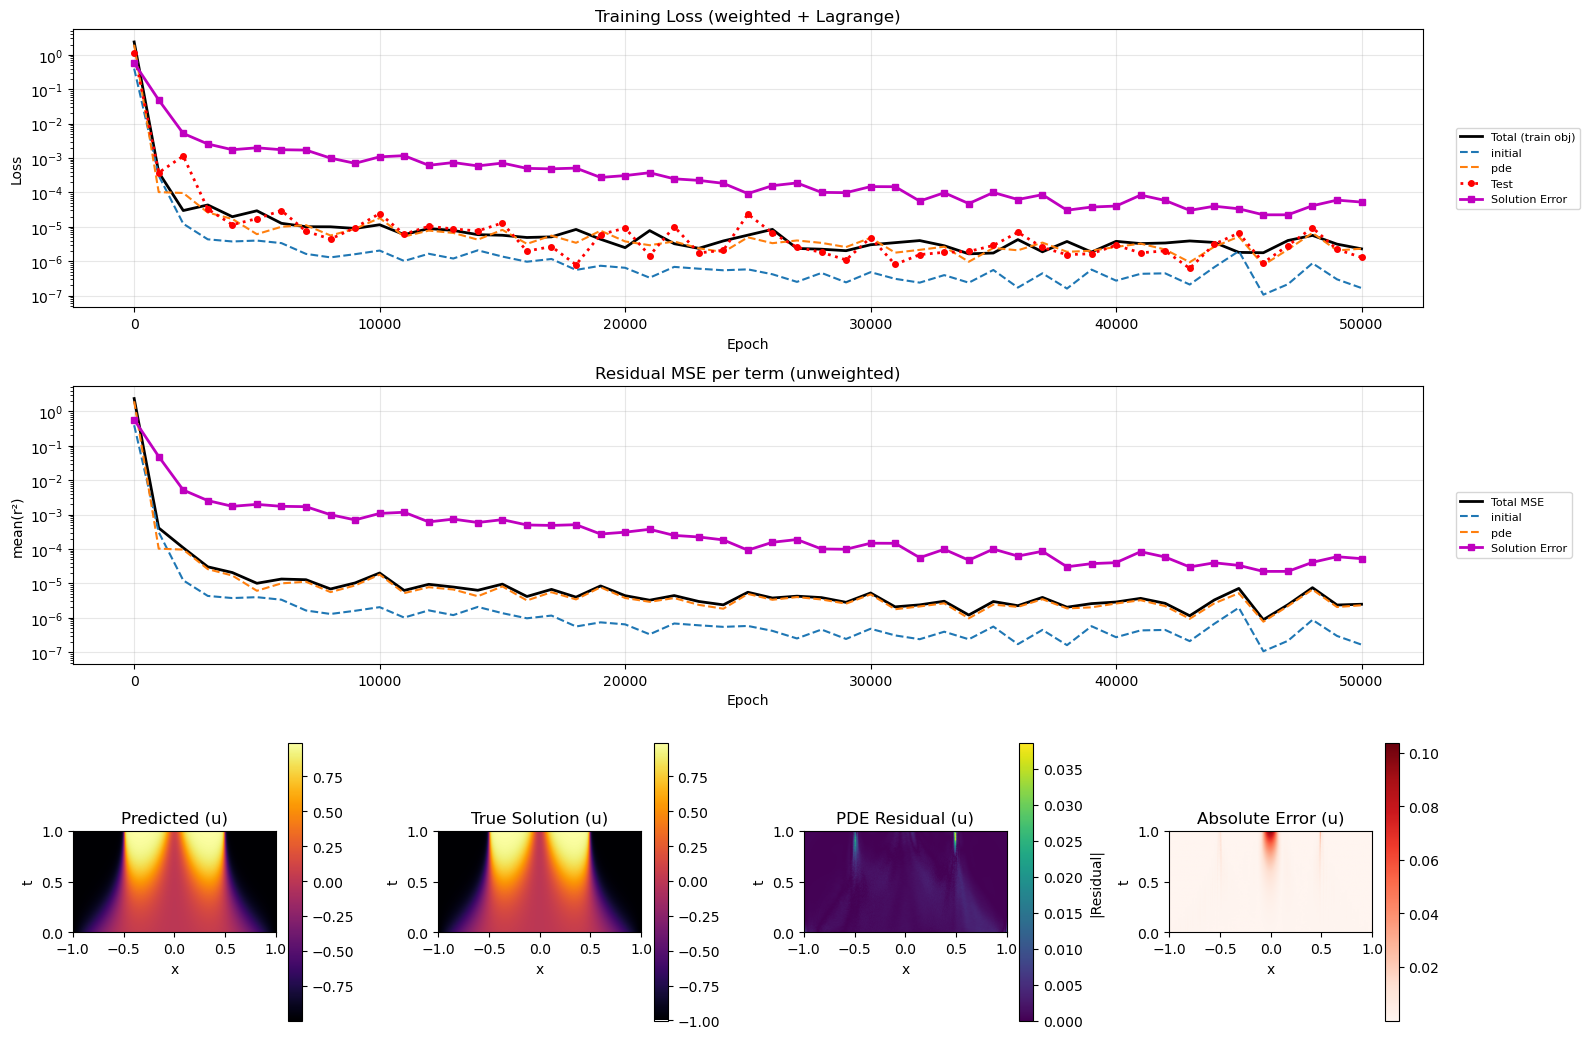

Epoch 0/50000 | Loss: 2.37e+00 | MSE: 2.37e+00 | Terms: [initial: 3.97e-01, pde: 1.97e+00] | Test Loss: 1.14e+00 | Error: 5.77e-01 | Time: 0.0s
Epoch 1000/50000 | Loss: 3.84e-04 | MSE: 4.11e-04 | Terms: [initial: 3.09e-04, pde: 1.02e-04] | Test Loss: 3.77e-04 | Error: 4.90e-02 | Time: 9.6s
Epoch 2000/50000 | Loss: 2.98e-05 | MSE: 1.09e-04 | Terms: [initial: 1.23e-05, pde: 9.65e-05] | Test Loss: 1.15e-03 | Error: 5.19e-03 | Time: 11.5s
Epoch 3000/50000 | Loss: 4.33e-05 | MSE: 3.04e-05 | Terms: [initial: 4.34e-06, pde: 2.61e-05] | Test Loss: 3.27e-05 | Error: 2.56e-03 | Time: 13.4s
Epoch 4000/50000 | Loss: 1.97e-05 | MSE: 2.07e-05 | Terms: [initial: 3.76e-06, pde: 1.70e-05] | Test Loss: 1.15e-05 | Error: 1.75e-03 | Time: 15.3s
Epoch 5000/50000 | Loss: 2.94e-05 | MSE: 1.01e-05 | Terms: [initial: 3.99e-06, pde: 6.12e-06] | Test Loss: 1.73e-05 | Error: 1.99e-03 | Time: 17.2s
Epoch 6000/50000 | Loss: 1.27e-05 | MSE: 1.34e-05 | Terms: [initial: 3.37e-06, pde: 1.01e-05] | Test Loss: 2.98e-05 |

In [6]:
trainer = pinns.Trainer(problem, network)

trainer.compile(
    problem = {
        "pde":      {"train": 1000, "test": 10, "weight": 1.0},
        "initial":  {"train": 200,  "test": 10, "weight": 1.0},
    },
    optimizer=pinns.SOAPOptimizer(),
    schedulers=[
        pinns.SchedulerResample(1000),
        pinns.SchedulerCausal(term="pde", tol=1.0, n_chunks=16, t_col=1),
        pinns.SchedulerLagrange(["pde"], lr=1e-3)
    ],
    epochs     = 50000,
    print_each = 1000,
)

trainer.train()